In [1]:
import numpy as np
import pandas as pd
import random
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report as classification_report_multiout
from itertools import product

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_P1_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_P1_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Thrace\GR_Thrace_WNV_Dataset_P1_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Attica\GR_Attica_WNV_Dataset_P1_2010_2023.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)


dataset1.head()

dataset2.head()

dataset3.head()

dataset4.head()

dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(308, 73)


In [2]:
dataset.head()

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2010,22.217953,40.552111,NaN,NaN,NaN,NaN,6.832007,10.274829,3.389185,-0.323333,1.440741,5.691801,524.456884,12.316395,1144.314815,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,5025.2,5265.4,49,"[0, 0, 6, 36, 7, 0]"
1,EL522,2010,23.139033,40.693632,0.246671,-0.155465,0.054331,-0.054331,7.666022,11.889764,3.442280,-2.889219,3.587031,4.429008,409.388384,11.673538,1084.539062,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,9804.6,10058.8,81,"[0, 0, 11, 50, 20, 0]"
2,EL523,2010,22.762317,41.016275,0.240682,-0.239834,-0.012466,0.012466,6.672266,11.074669,2.269862,-4.752826,1.986957,4.711003,434.944488,9.033014,839.043478,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,5916.0,24162.0,9803.0,39881.0,5598.0,23417.0,11860.0,40875.0,1169.86,5809.2,5920.4,23,"[0, 0, 6, 13, 4, 0]"
3,EL524,2010,22.109782,40.888821,0.242562,-0.053267,0.147196,-0.147196,6.576489,10.600797,2.552180,-3.833409,0.897500,5.741834,528.670447,10.937382,1016.011364,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,31,36,30,12,9,4,4,4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,5025.2,5265.4,57,"[0, 0, 3, 41, 13, 0]"
4,EL525,2010,22.442423,40.269959,NaN,NaN,NaN,NaN,8.062156,11.409259,4.715053,0.756667,4.043333,4.973131,459.127417,12.127033,1126.222222,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,31,36,30,12,12,1,6,7,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,10377.0,39695.0,11841.0,61913.0,10120.0,40015.0,14312.0,64447.0,1815.79,5025.2,5265.4,13,"[0, 0, 1, 7, 5, 0]"


In [3]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases_total'])
y = dataset['cases_arr']
s = dataset['cases_total']

In [4]:
n_folds = 10
#k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [5]:
features_to_remove = ['x', 'y', 'year', 'lc_prop1', 'lc_prop3', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names)

Index(['ndvi_p1', 'ndwi_p1', 'ndmi_p1', 'ndbi_p1', 'lst_mean_p1',
       'lst_day_mean_p1', 'lst_night_mean_p1', 'lst_min_p1', 'lst_max_p1',
       'prec_mean_p1', 'prec_acc_p1', 'mosq_mean_p1', 'mosq_sum_p1', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lc_prop2', 'lc_type2', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std',
       'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std',
       'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',
       'males_lt15', 'males_15t64', 'males_gt65', 'males_total',
       'females_lt15', 'females_15t64', 'females_gt65', 'females_total',
       'mio_eur', 'l_total', 'unl_total'],
      dtype='object')

In [6]:
## Grid Search

grid_search_results = []

param_grid = {
    'learning_rate': [0.3, 0.5, 0,6],
    'max_depth': [4, 6, 8],
    'n_estimators': [100, 200],
    'min_child_weight': [5, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0.2, 0.5],
    'reg_alpha': [0.2, 0.5],
    'scale_pos_weight': [1],
    'objective': ['binary:logistic'],
    'eval_metric': ['logloss'],
    'tree_method': ['hist'],
    'device': ['cuda']
}

param_combinations = list(product(*param_grid.values()))
print(f'Total param combinations {len(param_combinations)}')

import time

y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

best_model = None
training_loss = 0
testing_loss = 0
best_metric = 10**10

param_counter = 1
all_params = len(param_combinations)

start_time = time.time()

for params in param_combinations:
    if param_counter%50 == 0:
        print(f"Parameter Combination: {param_counter}/{all_params}")
    for train_idx, test_idx in k_fold.split(X):
        data_train = dataset.iloc[train_idx]
        data_test = dataset.iloc[test_idx]

        data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: json.loads(x))
        data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: np.array(x))
        data_train = convert_multiple_cases_array_weighted(data_train, target_col='cases_arr')
        data_train['cases_total'] = data_train['cases_total'].apply(lambda x: 1 if x > 0 else 0)

        data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: json.loads(x))
        data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: np.array(x))
        data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: np.where(x == 0, 0, 1))
        data_test['cases_total'] = data_test['cases_total'].apply(lambda x: 1 if x > 0 else 0)
        
        # duplicated_rows_test = data_test[data_test.duplicated(subset=data_test.columns[data_test.columns != 'cases_arr'])].index
        # data_test_no_duplicates = data_test.drop(duplicated_rows_test)

        data_train.reset_index(inplace = True, drop = True)
        data_test.reset_index(inplace = True, drop = True)

        X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases_total'])
        X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases_total'])

        y_train = data_train['cases_arr']
        y_test = data_test['cases_arr']
        
        scaler = MinMaxScaler()
        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
                
        imputer = KNNImputer()
        imputer.fit(X_train)
        X_train_imputed = imputer.transform(X_train_scaled)
        X_test_imputed = imputer.transform(X_test_scaled)

        y_train_np = np.stack(y_train.to_numpy())
        y_test_np = np.stack(y_test.to_numpy())

        model = xgb.XGBClassifier(learning_rate=params[0], max_depth=params[1], n_estimators=params[2], 
                                  min_child_weight=params[3], subsample=params[4], colsample_bytree=params[5],
                                  gamma=params[6], reg_alpha=params[7], scale_pos_weight=params[8],
                                  objective=params[9], eval_metric=params[10], tree_method=params[11], 
                                  device=params[12])   
        model_multiout =  ClassifierChain(model)
        trained_model = model_multiout.fit(X_train_imputed, y_train_np)

        y_train_prob = trained_model.predict_proba(X_train_imputed)
        y_test_prob = trained_model.predict_proba(X_test_imputed)

        y_train_list.append(y_train_np)
        y_test_list.append(y_test_np)
        y_train_prob_list.append(y_train_prob)
        y_test_prob_list.append(y_test_prob)
        

    y_train_true = np.concatenate(y_train_list, axis=0)
    y_test_true = np.concatenate(y_test_list, axis=0)

    y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
    y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

    train_loss = log_loss_vector(y_train_true, y_train_proba)
    test_loss = log_loss_vector(y_test_true, y_test_proba)

    metric = test_loss - train_loss

    if metric > 0:
        if metric < best_metric:
            best_metric = metric
            best_model = model
            training_loss = train_loss
            testing_loss = test_loss


    param_counter += 1

    grid_search_results.append({'train_loss': train_loss, 
                                'test_loss': test_loss,
                                'metric': metric, 
                                'params': model.get_params()})
    
grid_search_df = pd.DataFrame(grid_search_results)

end_time = time.time()
print(f'Elapsed Time: {end_time-start_time} sec')
print('\n')
print(training_loss)
print(testing_loss)
print(best_metric)
print('\n')
print(best_model.get_params())

Total param combinations 768
Parameter Combination: 50/768
Parameter Combination: 100/768
Parameter Combination: 150/768
Parameter Combination: 200/768
Parameter Combination: 250/768
Parameter Combination: 300/768
Parameter Combination: 350/768
Parameter Combination: 400/768
Parameter Combination: 450/768
Parameter Combination: 500/768
Parameter Combination: 550/768
Parameter Combination: 600/768
Parameter Combination: 650/768
Parameter Combination: 700/768
Parameter Combination: 750/768
Elapsed Time: 12569.334730863571 sec


0.17962989618140043
0.46493476646935006
0.2853048702879496


{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': 'cuda', 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'gamma': 0.5, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0, 

In [10]:
grid_search_df.to_csv(r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Grid_Search\GR_Modeling_&_Training_P1_2010-2023_xgb_kfold_array_vectorleaf_gridsearch.csv', encoding = 'utf-8', index = False)

#read next time

In [32]:
params = grid_search_df[grid_search_df.metric == grid_search_df.metric.min()].params
params = params.to_dict()[next(iter(params.to_dict()))]

In [33]:
# ## XGBoost Model Parameters (previous best)

# params = {
#     "objective": "binary:logistic",
#     "multi_strategy": "multi_output_tree", 
#     "colsample_bytree": 1.0, 
#     "device": "cpu", 
#     "eval_metric": "logloss",
#     "gamma": 0.5, 
#     "learning_rate": 0.3, 
#     "max_depth": 4, 
#     "min_child_weight": 5, 
#     "n_estimators": 100, 
#     "reg_alpha": 0.5, 
#     "scale_pos_weight": 1, 
#     "subsample": 1.0, 
#     "tree_method": "hist"

#     }

In [6]:
## XGBoost Model Parameters

params = {
    "objective": "binary:logistic",
    "multi_strategy": "multi_output_tree", 
    "device": "cpu", 
    "eval_metric": "logloss",
    "max_depth": 4, 
    "scale_pos_weight": 1, 
    }

In [7]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X, s):
    print(f'Fold: {fold_counter+1}/{n_folds}')
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: json.loads(x))
    data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: np.array(x))
    data_train = convert_multiple_cases_array_weighted(data_train, target_col='cases_arr')
    data_train['cases_total'] = data_train['cases_total'].apply(lambda x: 1 if x > 0 else 0)

    data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: json.loads(x))
    data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: np.array(x))
    data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: np.where(x == 0, 0, 1))
    data_test['cases_total'] = data_test['cases_total'].apply(lambda x: 1 if x > 0 else 0)
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases_total'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases_total'])

    y_train = data_train['cases_arr']
    y_test = data_test['cases_arr']

    print(f"Training set 0/1 Ratio: {(data_train['cases_total'].value_counts().get(0) / data_train['cases_total'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['cases_total'].value_counts().get(0) / data_test['cases_total'].value_counts().get(1)):.2f}")
    
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    y_train_np = np.stack(y_train.to_numpy())
    y_test_np = np.stack(y_test.to_numpy())

    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_imputed, y_train_np)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train_np)
    y_test_list.append(y_test_np)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/10
Training set 0/1 Ratio: 0.34
Test set 0/1 Ratio: 0.72
Fold: 2/10
Training set 0/1 Ratio: 0.35
Test set 0/1 Ratio: 1.21
Fold: 3/10
Training set 0/1 Ratio: 0.32
Test set 0/1 Ratio: 1.07
Fold: 4/10
Training set 0/1 Ratio: 0.31
Test set 0/1 Ratio: 1.58
Fold: 5/10
Training set 0/1 Ratio: 0.39
Test set 0/1 Ratio: 1.58
Fold: 6/10
Training set 0/1 Ratio: 0.33
Test set 0/1 Ratio: 0.94
Fold: 7/10
Training set 0/1 Ratio: 0.33
Test set 0/1 Ratio: 1.21
Fold: 8/10
Training set 0/1 Ratio: 0.31
Test set 0/1 Ratio: 1.58
Fold: 9/10
Training set 0/1 Ratio: 0.34
Test set 0/1 Ratio: 2.33
Fold: 10/10
Training set 0/1 Ratio: 0.31
Test set 0/1 Ratio: 2.33


In [8]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [9]:
train_loss = log_loss_vector(y_train_true, y_train_proba)
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss_vector(y_test_true, y_test_proba)
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0108
Test Loss: 0.3732


In [10]:
classification_thresholds = optimal_threashold_fbeta_vector(y_train_proba, y_train_true, beta = 2, round_factor = 2)
print(classification_thresholds)

[0.81 0.69 0.76 0.81 0.76 0.7 ]


In [11]:
# classification_thresholds_test = optimal_threashold_fbeta_vector(y_test_proba, y_test_true, beta = 2, round_factor = 2)
# print(classification_thresholds_test)

In [12]:
y_train_pred = np.where(y_train_proba < classification_thresholds, 0, 1)
y_test_pred = np.where(y_test_proba < classification_thresholds, 0, 1)

In [13]:
# y_train_pred_with_test = np.where(y_train_proba < classification_thresholds_test, 0, 1)
# y_test_pred_with_test = np.where(y_test_proba < classification_thresholds_test, 0, 1)

In [14]:
hm_loss = hamming_loss(y_test_true, y_test_pred)
print(f"Hamming Loss: {hm_loss}")

Hamming Loss: 0.13365800865800867


In [15]:
print(classification_report_multiout(y_test_true, y_test_pred, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October']))

              precision    recall  f1-score   support

         May       0.00      0.00      0.00         1
        June       0.00      0.00      0.00         4
        July       0.50      0.10      0.16        62
      August       0.80      0.49      0.61       114
   September       0.74      0.45      0.56       102
     October       0.50      0.08      0.14        36

   micro avg       0.74      0.35      0.47       319
   macro avg       0.42      0.19      0.25       319
weighted avg       0.68      0.35      0.44       319
 samples avg       0.19      0.15      0.16       319



In [16]:
# print(classification_report_multiout(y_test_true, y_test_pred_with_test, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October']))

In [17]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''
labels = [0,1,2,3,4,5]

cm = multilabel_confusion_matrix(y_test_true, y_test_pred, labels=labels)

print(cm)
print('\n')
print(np.sum(cm, axis=0))

[[[307   0]
  [  1   0]]

 [[304   0]
  [  4   0]]

 [[240   6]
  [ 56   6]]

 [[180  14]
  [ 58  56]]

 [[190  16]
  [ 56  46]]

 [[269   3]
  [ 33   3]]]


[[1490   39]
 [ 208  111]]


In [18]:
# cm = multilabel_confusion_matrix(y_test_true, y_test_pred_with_test, labels=labels)

# print(cm)
# print('\n')
# print(np.sum(cm, axis=0))

In [19]:
##TODO cells for shap values are incomplete

In [21]:
X_train = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove)
y_train = y

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)

y_train_np = np.stack(y_train.to_numpy())

In [22]:
## Tree explainer

## curently not working with multioutput models

# model = xgb.XGBClassifier(**params)   
# trained_model = model.fit(X_train_imputed, y_train_np)

# explainer = shap.TreeExplainer(model)
# tree_shap_values = explainer.shap_values(X_train_imputed)

In [23]:
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train_np)

explainer = shap.KernelExplainer(trained_model.predict_proba, X_train_imputed, link = 'logit', feature_names=X_train.columns)
# explainer = shap.KernelExplainer(trained_model.predict_proba, shap.kmeans(X_train_imputed, 20), link = 'logit')

Using 727 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [24]:
# shap_values = explainer.shap_values(X_train_imputed)

In [25]:
shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_P1_2010-2023_Shapely_Values_vectorleaf.npz'

# np.savez(shap_values_path, *shap_values)

shap_values = []
loaded_shap_values = np.load(shap_values_path)

for key in loaded_shap_values.keys():
    shap_values.append(loaded_shap_values[key])

In [39]:
X_train_imputed.shape

(727, 61)

In [40]:
shap_values[1].shape

(727, 61)

In [26]:
location_columns = dataset.iloc[:, :4]
wnv_columns = dataset.iloc[:, -1:]

In [27]:
shap_values_may = pd.DataFrame(shap_values[0], columns=X_train.columns)
shap_values_may = pd.concat([location_columns, shap_values_may, wnv_columns], axis=1)
shap_values_may['cases_arr'] = shap_values_may['cases_arr'].apply(lambda x: x[0])
shap_values_may.insert(loc=2, column='month', value=5)
shap_values_jun = pd.DataFrame(shap_values[1], columns=X_train.columns)
shap_values_jun = pd.concat([location_columns, shap_values_jun, wnv_columns], axis=1)
shap_values_jun['cases_arr'] = shap_values_jun['cases_arr'].apply(lambda x: x[1])
shap_values_jun.insert(loc=2, column='month', value=6)
shap_values_jul = pd.DataFrame(shap_values[2], columns=X_train.columns)
shap_values_jul = pd.concat([location_columns, shap_values_jul, wnv_columns], axis=1)
shap_values_jul['cases_arr'] = shap_values_jul['cases_arr'].apply(lambda x: x[2])
shap_values_jul.insert(loc=2, column='month', value=7)
shap_values_aug = pd.DataFrame(shap_values[3], columns=X_train.columns)
shap_values_aug = pd.concat([location_columns, shap_values_aug, wnv_columns], axis=1)
shap_values_aug['cases_arr'] = shap_values_aug['cases_arr'].apply(lambda x: x[3])
shap_values_aug.insert(loc=2, column='month', value=8)
shap_values_sep = pd.DataFrame(shap_values[4], columns=X_train.columns)
shap_values_sep = pd.concat([location_columns, shap_values_sep, wnv_columns], axis=1)
shap_values_sep['cases_arr'] = shap_values_sep['cases_arr'].apply(lambda x: x[4])
shap_values_sep.insert(loc=2, column='month', value=9)
shap_values_oct = pd.DataFrame(shap_values[5], columns=X_train.columns)
shap_values_oct = pd.concat([location_columns, shap_values_oct, wnv_columns], axis=1)
shap_values_oct['cases_arr'] = shap_values_oct['cases_arr'].apply(lambda x: x[5])
shap_values_oct.insert(loc=2, column='month', value=10)

In [28]:
shap_values_df = pd.concat([shap_values_may, shap_values_jun, shap_values_jul, shap_values_aug, shap_values_sep, shap_values_oct], axis=0)
shap_values_df.sort_values(by=['year', 'month', 'NUTS3_ID'], ascending=True, inplace=True)
shap_values_df.reset_index(drop=True, inplace=True)

In [29]:
shap_values_df

,NUTS3_ID,year,month,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop2,lc_type2,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_arr
0,EL301,2010,5,23.825080,38.055971,-0.058087,0.138860,0.000000,0.000000,-0.009491,0.000000,-0.040347,0.000000,0.103814,-0.025842,0.000000,0.102866,0.0,-0.005994,0.137580,-0.069648,0.230646,0.000000,-0.053284,0.019929,-0.140976,-0.022172,0.000000,-0.010092,-0.047734,-0.104829,0.030445,-0.110557,0.000000,-0.099963,0.064606,-0.045009,0.152358,0.00000,0.000000,-0.006480,0.000000,-0.004469,0.000000,0.0,0.0,0.169293,0.017987,0.010536,0.000000,0.000000,0.000000,0.0,0.00000,0.042315,-0.010382,0.000000,-0.071221,0.022121,-0.014011,0.0,0.000000,-0.004369,-0.008934,-0.049405,-0.102609,0
1,EL302,2010,5,23.686502,38.024894,-0.104677,0.066641,0.000000,0.015635,0.019622,0.061007,-0.043459,-0.079832,0.211233,-0.121205,0.004389,0.101958,0.0,0.000000,0.084318,0.022336,0.194282,0.000000,-0.051799,0.000000,0.122125,-0.025521,0.000000,0.182265,-0.060020,-0.072721,0.014129,-0.112634,0.000000,-0.097860,0.066082,-0.046943,0.156982,0.00000,0.000000,0.029231,0.000000,0.000000,0.022872,0.0,0.0,0.119278,0.031587,0.014455,0.000000,0.000000,0.000000,0.0,0.00000,0.039259,-0.068175,0.000000,-0.074575,0.000000,0.000000,0.0,-0.027989,0.000000,-0.008973,-0.046946,-0.101430,0
2,EL303,2010,5,23.757527,37.973503,-0.088269,0.075535,0.000000,-0.006497,0.018571,0.000000,-0.043935,-0.085508,0.088702,-0.078552,0.000000,0.098468,0.0,-0.010558,0.324214,-0.074084,-0.201905,0.000000,-0.056420,-0.035574,0.169612,-0.008705,0.000000,0.194453,-0.107816,-0.073410,-0.059551,-0.106990,-0.009087,0.194531,0.073955,-0.042169,0.053890,0.00000,0.000000,0.026291,0.000000,0.000000,0.026245,0.0,0.0,0.135869,0.028897,0.000000,0.000000,-0.005944,0.000000,0.0,0.00809,0.036567,0.064639,0.019279,-0.063359,0.024409,0.000000,0.0,0.000000,0.000000,0.014327,-0.054265,-0.083936,0
3,EL304,2010,5,23.745366,37.906427,-0.042813,0.158720,0.000000,0.010487,0.102396,0.000000,-0.038711,0.000000,0.074295,0.031055,0.000000,0.100252,0.0,0.000000,0.265499,0.000000,-0.206919,0.000000,-0.042941,-0.038537,-0.080531,-0.008040,0.000000,0.025915,-0.112171,-0.074711,-0.044904,-0.107499,-0.011253,0.200806,-0.045044,-0.040401,0.058275,0.00000,0.000000,-0.008891,-0.005487,0.000000,0.021400,0.0,0.0,0.138032,0.009270,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.041275,-0.047218,0.000000,-0.065530,0.000000,-0.013694,0.0,0.000000,0.000000,0.013716,-0.046952,-0.100150,0
4,EL305,2010,5,23.886562,38.040564,0.279484,0.000000,0.000000,0.048898,-0.023080,-0.007393,-0.022061,0.000000,0.115611,-0.069652,0.000000,0.018736,0.0,0.000000,-0.031951,-0.267645,-0.161869,0.000000,-0.054495,0.016968,-0.084154,-0.007499,0.000000,0.000000,-0.055807,-0.058663,0.026229,-0.112614,0.000000,0.269118,-0.018422,-0.073172,-0.008256,0.00000,0.000000,0.024525,-0.006883,0.000000,-0.031831,0.0,0.0,-0.087146,0.000000,0.012288,0.000000,0.000000,0.000000,0.0,0.00000,-0.010696,-0.040579,0.000000,-0.067013,0.000000,-0.013895,0.0,-0.024192,0.000000,0.035141,-0.037506,-0.102082,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4357,EL611,2023,10,21.720538,39.507246,0.262664,0.337241,0.024495,0.000000,0.000000,0.000000

In [30]:
condition_1 = (shap_values_df['NUTS3_ID'] == 'EL301') & (shap_values_df['year'] == 2010) & (shap_values_df['cases_arr'] == 0)
condition_2 = (shap_values_df['NUTS3_ID'].str.startswith('EL30')) & (shap_values_df['year'] == 2010)

shap_values_df_one = shap_values_df[condition_1].iloc[:, 5:-1].to_numpy()
shap_values_df_two = shap_values_df[condition_2].iloc[:, 5:-1].to_numpy()

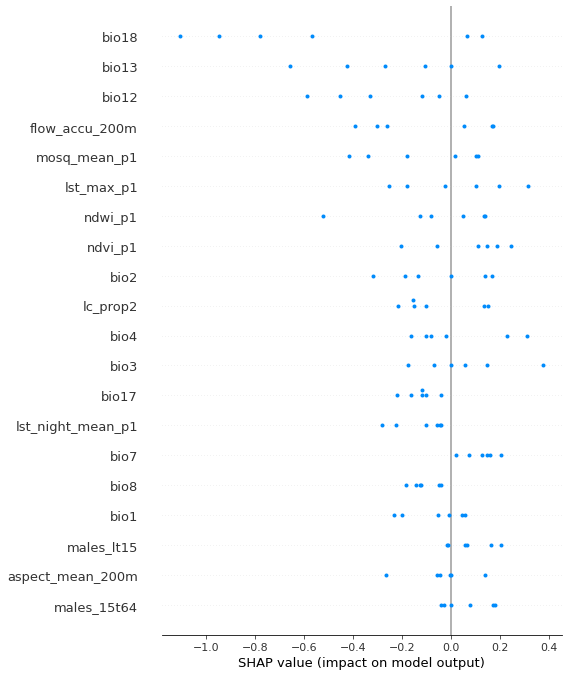

In [31]:
shap.summary_plot(shap_values = shap_values_df_one, features = feature_names)

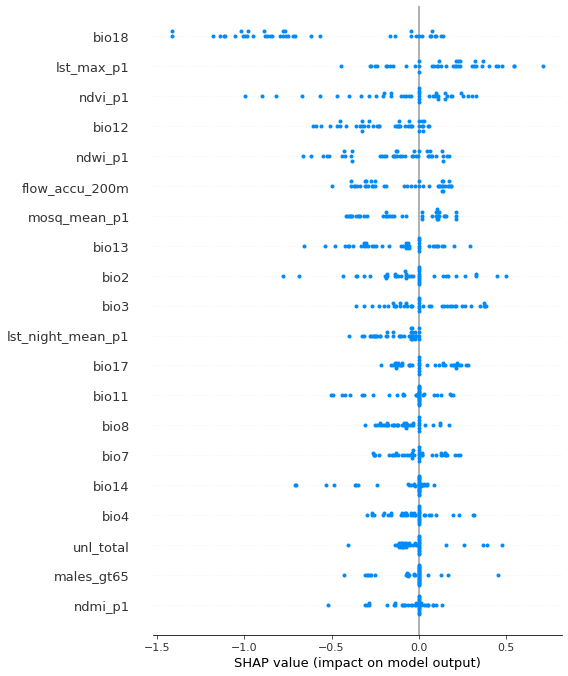

In [46]:
shap.summary_plot(shap_values = shap_values_df_two, features = feature_names)

In [33]:
shap_values_total = np.concatenate(shap_values, axis=0)

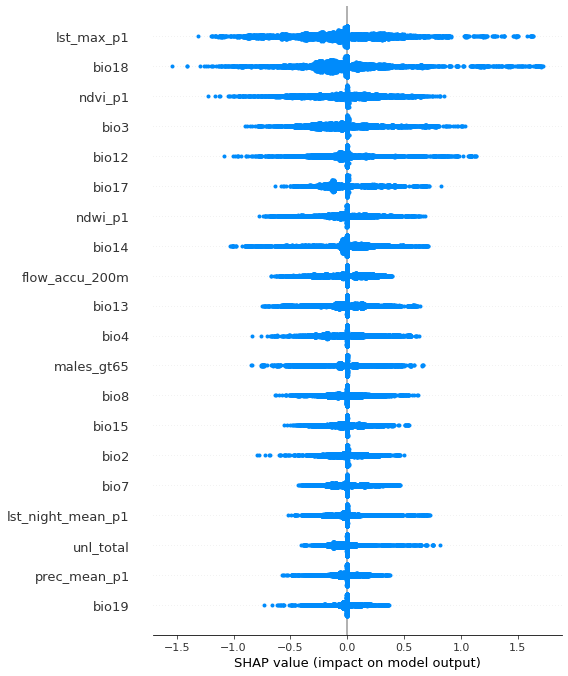

In [34]:
shap.summary_plot(shap_values = shap_values_total, features = feature_names)

In [35]:
shap.initjs()

shap.force_plot(explainer.expected_value[0], shap_values[0].iloc[0,:], X_train_imputed.iloc[0,:], feature_names = feature_names)

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
explainer.expected_value[0]

-4.961233844427854

In [ ]:
shap_values[0].shape

(727, 61)

In [ ]:
X_train_imputed.shape

(727, 61)

In [ ]:
# mean_shap = shap_values_total.mean(axis=0)
# shp = mean_shap.shape[0]
# mean_shap = mean_shap.reshape(1,shp)

# shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

# shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

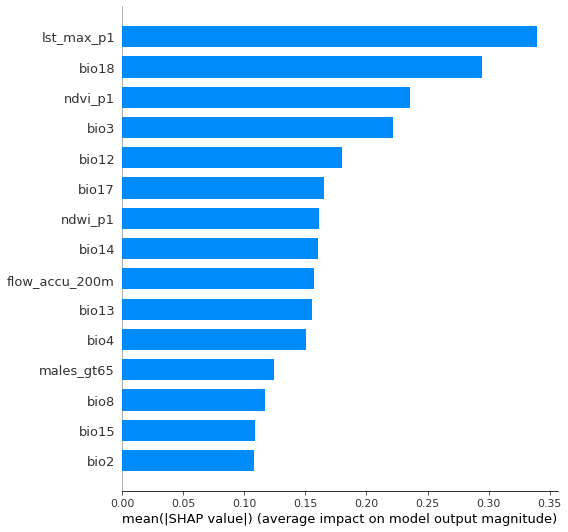

In [ ]:
shap.summary_plot(shap_values_total, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

In [ ]:
enviromental = ['ndvi_p1','ndwi_p1','ndmi_p1','ndbi_p1']
climate = ['lst_mean_p1', 'lst_day_mean_p1', 'lst_night_mean_p1', 'lst_min_p1', 'lst_max_p1', 'prec_mean_p1', 'prec_acc_p1',]
vectors = ['mosq_mean_p1', 'mosq_sum_p1',]
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
landuse = ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',]
demographic = ['males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_total',]
economics = ['mio_eur', 'l_total', 'unl_total',]

In [ ]:
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_landuse = shaps.loc[shaps['features'].isin(landuse)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_economics = shaps.loc[shaps['features'].isin(economics)].drop(columns=['weights'])

categories = {'Category': ['enviromental', 'climate', 'vectors', 'bioclimatic', 'landuse', 'geomorphological', 'demographic', 'economics'], 
              'Mean_Shap': [df_enviromental.weights_abs.sum(),df_climate.weights_abs.sum(),df_vectors.weights_abs.sum(),
                            df_bioclimatic.weights_abs.sum(),df_landuse.weights_abs.sum(),df_geomorphological.weights_abs.sum(),
                            df_demographic.weights_abs.sum(), df_economics.weights_abs.sum()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,8)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Cumulative Shap', figure_size = (8, 4))

NameError: name 'shaps' is not defined

,features,weights
1,climate,0.011674
7,economics,0.011155
2,vectors,0.010875
0,enviromental,0.010627
3,bioclimatic,0.007428
6,demographic,0.006682
5,geomorphological,0.004511
4,landuse,0.002930


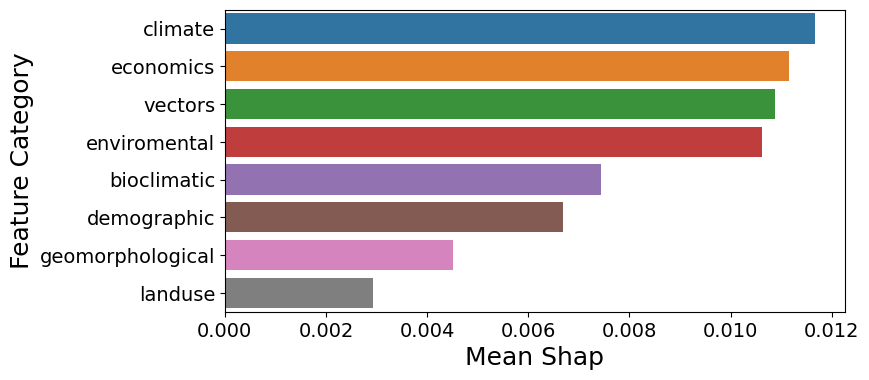

In [ ]:
categories = {'Category': ['enviromental', 'climate', 'vectors', 'bioclimatic', 'landuse', 'geomorphological', 'demographic', 'economics'], 
              'Mean_Shap': [df_enviromental.weights_abs.mean(),df_climate.weights_abs.mean(),df_vectors.weights_abs.mean(),
                            df_bioclimatic.weights_abs.mean(),df_landuse.weights_abs.mean(),df_geomorphological.weights_abs.mean(),
                            df_demographic.weights_abs.mean(), df_economics.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,8)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))